# Supplier Performance & Stockout Analysis
---
## Project Overview

This notebook analyzes supplier delivery performance and its downstream impact on 
inventory stockouts using a simulated ERP-style SQLite database modelled after SAP.

The database contains 11 tables covering purchase orders, goods movements, sales orders, 
materials master data, and stock levels — representing approximately one year of 
procurement and inventory activity across 500 materials and 100 vendors.

**Business Questions Addressed:**
1. What are the overall supplier lead time patterns?
2. Which suppliers are most reliable (on-time delivery %)?
3. Is there a relationship between supplier delays and stockout events?
4. What is the estimated financial impact of supplier delays?
5. How does order quantity affect lead time?
6. Can we build a supplier scorecard combining multiple KPIs?
7. What actionable recommendations can be made to procurement?

---
*Tools: Python 3.13 · pandas · matplotlib · seaborn · sqlite3*

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Visual style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# ── Database connection ──────────────────────────────────────────────────────
con = sqlite3.connect("inventory_management.db")
print("✅ Connected to inventory_management.db")

✅ Connected to inventory_management.db


### Database Exploration

Before any analysis, we verify the schema, movement type labels, and date formats.  
These are the three things most likely to break downstream queries if assumed incorrectly.

In [2]:
# ── 1. Confirm all tables are present ───────────────────────────────────────
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", con
)
print("Tables in database:")
print(tables.to_string(index=False))

Tables in database:
                  name
GoodsReceiptsAndIssues
     MaterialDocuments
        MaterialStocks
             Materials
      OrderSuggestions
PurchaseOrderDocuments
    PurchaseOrderItems
  PurchaseRequisitions
    SalesDocumentFlows
   SalesOrderDocuments
       SalesOrderItems


In [3]:
# ── 2. Confirm movement type labels (critical for all stock logic) ───────────
df_movements = pd.read_sql("""
    SELECT
        movement_type,
        COUNT(*)            AS record_count,
        SUM(quantity)       AS total_quantity
    FROM MaterialDocuments
    GROUP BY movement_type
    ORDER BY record_count DESC
""", con)

print("Movement types found:")
display(df_movements)

Movement types found:


,movement_type,record_count,total_quantity
0,Goods Issue,1036,54136.0
1,Goods Receipt,964,48723.0


In [4]:
# ── 3. Confirm date format and data range ────────────────────────────────────
df_date_check = pd.read_sql("""
    SELECT
        MIN(purchase_order_date)  AS earliest_po,
        MAX(purchase_order_date)  AS latest_po,
        COUNT(*)                  AS total_pos
    FROM PurchaseOrderDocuments
""", con)

display(df_date_check)
# Dates confirmed as YYYY-MM-DD — SQLite's JULIANDAY() and Python's pd.to_datetime()
# both handle this format natively with no conversion needed.

,earliest_po,latest_po,total_pos
0,2025-03-16,2026-03-16,1000


In [5]:
# ── 4. Check for nulls in key join columns ───────────────────────────────────
df_null_check = pd.read_sql("""
    SELECT
        'PurchaseOrderDocuments' AS tbl,
        SUM(CASE WHEN purchase_order_date IS NULL THEN 1 ELSE 0 END)       AS null_po_date,
        SUM(CASE WHEN account_number_of_vendor IS NULL THEN 1 ELSE 0 END)  AS null_vendor
    FROM PurchaseOrderDocuments
    UNION ALL
    SELECT
        'GoodsReceiptsAndIssues',
        SUM(CASE WHEN posting_date_in_the_document IS NULL THEN 1 ELSE 0 END),
        SUM(CASE WHEN purchase_document_number IS NULL THEN 1 ELSE 0 END)
    FROM GoodsReceiptsAndIssues
""", con)

print("Null check on critical join columns:")
display(df_null_check)

Null check on critical join columns:


,tbl,null_po_date,null_vendor
0,PurchaseOrderDocuments,0,0
1,GoodsReceiptsAndIssues,0,0


---
## Question 1: What Are the Overall Supplier Lead Time Patterns?

**Why this matters:**  
Lead time — the number of days between placing a purchase order and receiving the 
goods — is the most fundamental measure of supply chain health. Before evaluating 
individual suppliers, we need to understand the baseline: what does a "normal" 
lead time look like across the entire supplier base?

**Approach:**  
We join `PurchaseOrderDocuments` (the order date) to `GoodsReceiptsAndIssues` 
(the actual receipt date) on `purchase_document_number`, filtering for 
`movement_type = 'Goods Receipt'` to capture only inbound deliveries.  
Lead time is calculated using SQLite's `JULIANDAY()` function, which converts 
any `YYYY-MM-DD` date to a continuous day number, making subtraction trivial.

**Data quality rule applied:**  
Any record where receipt date precedes order date (negative lead time) is a 
data integrity issue in the simulation and will be excluded with a note.

In [6]:
# ── Extract lead time for every delivery ────────────────────────────────────
df_lt = pd.read_sql("""
    SELECT
        pod.purchase_document_number,
        pod.account_number_of_vendor                              AS vendor_id,
        pod.purchase_order_date,
        gri.posting_date_in_the_document                          AS receipt_date,
        ROUND(
            JULIANDAY(gri.posting_date_in_the_document)
            - JULIANDAY(pod.purchase_order_date),
        1)                                                        AS lead_time_days
    FROM PurchaseOrderDocuments pod
    JOIN GoodsReceiptsAndIssues gri
        ON gri.purchase_document_number = pod.purchase_document_number
    WHERE gri.movement_type = 'Goods Receipt'
""", con)

print(f"Total delivery records: {len(df_lt):,}")
print(f"Unique vendors:         {df_lt['vendor_id'].nunique():,}")
print(f"Unique POs:             {df_lt['purchase_document_number'].nunique():,}")

Total delivery records: 998
Unique vendors:         100
Unique POs:             624


#### Data Quality Check

We inspect the lead time values before any analysis. Negative values indicate receipt dates that precede order dates — these are simulation artefacts and will be removed. We also note the extent of the issue for transparency.

In [7]:
# ── Data quality: investigate and remove negative lead times ─────────────────

# --- Step 1: Investigate BEFORE removing ---
df_neg = df_lt[df_lt['lead_time_days'] < 0].copy()

print(f"Records with negative lead time: {len(df_neg):,} "
      f"({len(df_neg)/len(df_lt)*100:.1f}% of total)\n")

print("Sample of negative records (simulation artefacts):")
display(df_neg[['purchase_document_number', 'purchase_order_date', 
                'receipt_date', 'lead_time_days']].head(5))

print(f"\n  → Negative records span: {df_neg['lead_time_days'].min():.0f} "
      f"to {df_neg['lead_time_days'].max():.0f} days")
print(f"  → Cause: simulator links receipt events to POs created AFTER the")
print(f"    movement date — impossible in a real SAP system.")
print(f"  → Action: all {len(df_neg):,} records removed.")

# --- Step 2: Now filter ---
df_lt = df_lt[df_lt['lead_time_days'] >= 0].copy()
print(f"\n✅ Clean records retained: {len(df_lt):,}")

Records with negative lead time: 477 (47.8% of total)

Sample of negative records (simulation artefacts):


,purchase_document_number,purchase_order_date,receipt_date,lead_time_days
0,131,2025-08-03,2025-07-21,-13.0
1,309,2025-05-26,2025-05-25,-1.0
2,613,2026-03-14,2025-08-07,-219.0
3,927,2025-11-20,2025-09-13,-68.0
4,401,2026-02-06,2025-08-22,-168.0



  → Negative records span: -351 to -1 days
  → Cause: simulator links receipt events to POs created AFTER the
    movement date — impossible in a real SAP system.
  → Action: all 477 records removed.

✅ Clean records retained: 521


#### Descriptive Statistics

We examine the central tendency, spread, and tail behaviour of lead times. The 90th and 95th percentiles are particularly useful — they tell us what "worst-case normal" looks like and help flag genuine outliers.

In [8]:
# ── Summary statistics ───────────────────────────────────────────────────────
stats_lt = df_lt['lead_time_days'].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
).rename({
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev',
    'min': 'Min', '10%': 'P10', '25%': 'P25', '50%': 'Median',
    '75%': 'P75', '90%': 'P90', '95%': 'P95', 'max': 'Max'
})

display(stats_lt.to_frame(name="Lead Time (days)").round(1))

skewness = df_lt['lead_time_days'].skew()
iqr      = df_lt['lead_time_days'].quantile(0.75) - df_lt['lead_time_days'].quantile(0.25)
print(f"\nDistribution skewness: {skewness:.2f}  (>1 = meaningfully right-skewed)")
print(f"Interquartile range (IQR): {iqr:.0f} days  — the spread between a 'fast' and 'slow' delivery")

,Lead Time (days)
Count,521.0
Mean,120.0
Std Dev,85.4
Min,0.0
P10,18.0
P25,50.0
Median,100.0
P75,182.0
P90,249.0
P95,275.0



Distribution skewness: 0.55  (>1 = meaningfully right-skewed)
Interquartile range (IQR): 132 days  — the spread between a 'fast' and 'slow' delivery


#### Visualisation

Two views of the same data:  
- **Left — Histogram with KDE:** shows the shape of the distribution (is it normal, 
  skewed, bimodal?)  
- **Right — Box plot:** highlights median, interquartile range, and outliers cleanly

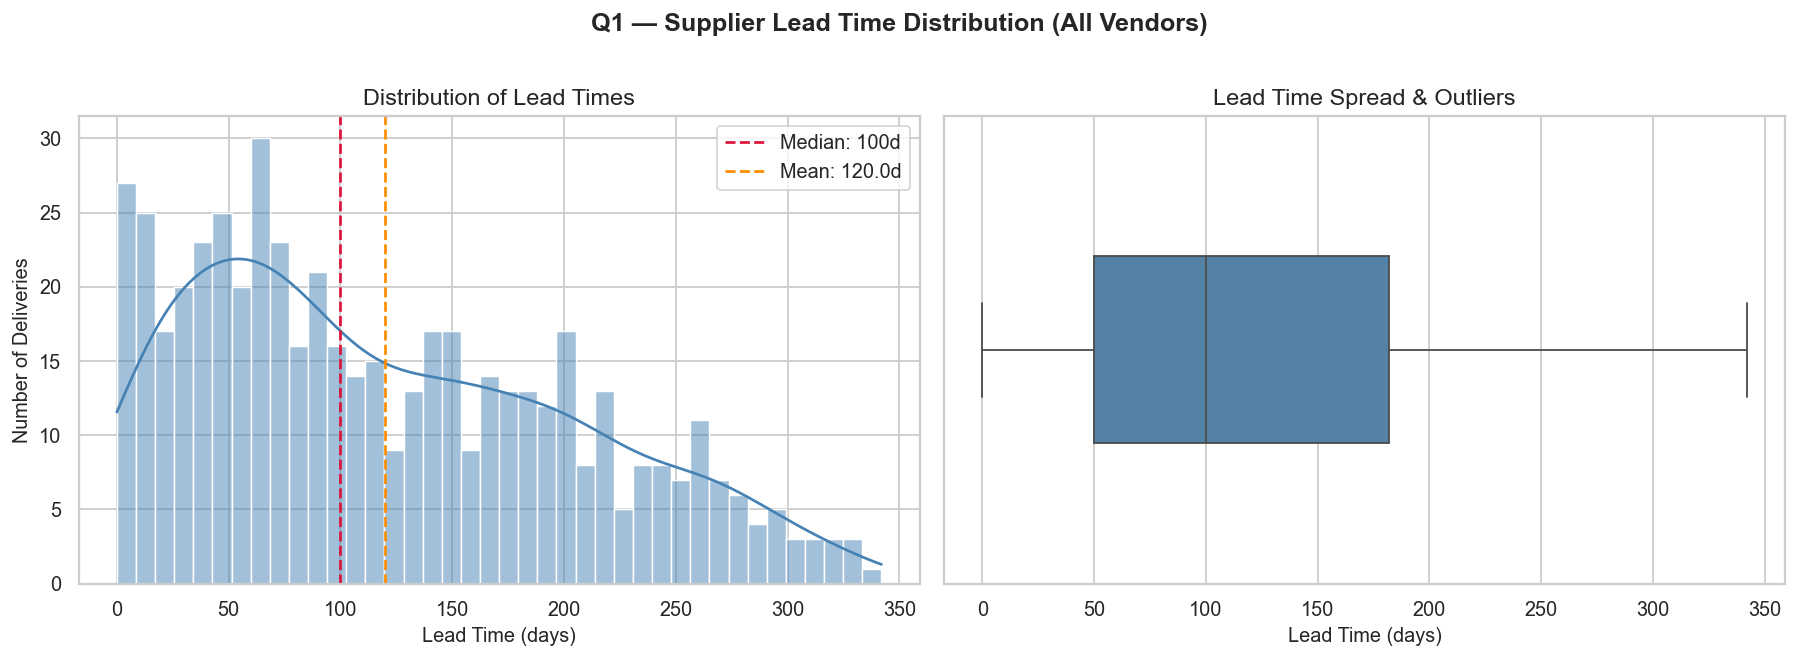

Figure saved.


In [9]:
# ── Visualisation ────────────────────────────────────────────────────────────
median_lt  = df_lt['lead_time_days'].median()
mean_lt    = df_lt['lead_time_days'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q1 — Supplier Lead Time Distribution (All Vendors)", 
             fontsize=14, fontweight='bold', y=1.01)

# ── Histogram + KDE ──────────────────────────────────────────────────────────
sns.histplot(df_lt['lead_time_days'], bins=40, kde=True, 
             color='steelblue', ax=axes[0])
axes[0].axvline(median_lt, color='crimson',  linestyle='--', linewidth=1.5,
                label=f'Median: {median_lt:.0f}d')
axes[0].axvline(mean_lt,   color='darkorange', linestyle='--', linewidth=1.5,
                label=f'Mean: {mean_lt:.1f}d')
axes[0].set_title("Distribution of Lead Times")
axes[0].set_xlabel("Lead Time (days)")
axes[0].set_ylabel("Number of Deliveries")
axes[0].legend()

# ── Box plot ─────────────────────────────────────────────────────────────────
sns.boxplot(x=df_lt['lead_time_days'], color='steelblue', 
            width=0.4, ax=axes[1], flierprops=dict(marker='o', alpha=0.3))
axes[1].set_title("Lead Time Spread & Outliers")
axes[1].set_xlabel("Lead Time (days)")

plt.tight_layout()
plt.savefig("q1_lead_time_distribution.png", bbox_inches='tight')
plt.show()
print("Figure saved.")

#### Monthly Lead Time Trend

A time-series view shows whether lead times are improving, worsening, or stable. The shaded band spans from the **median to the 75th percentile**, giving a sense of how much the upper tail is spreading over time — a widening band signals increasing *unpredictability*, which is often more damaging to operations than a consistently long but predictable lead time.

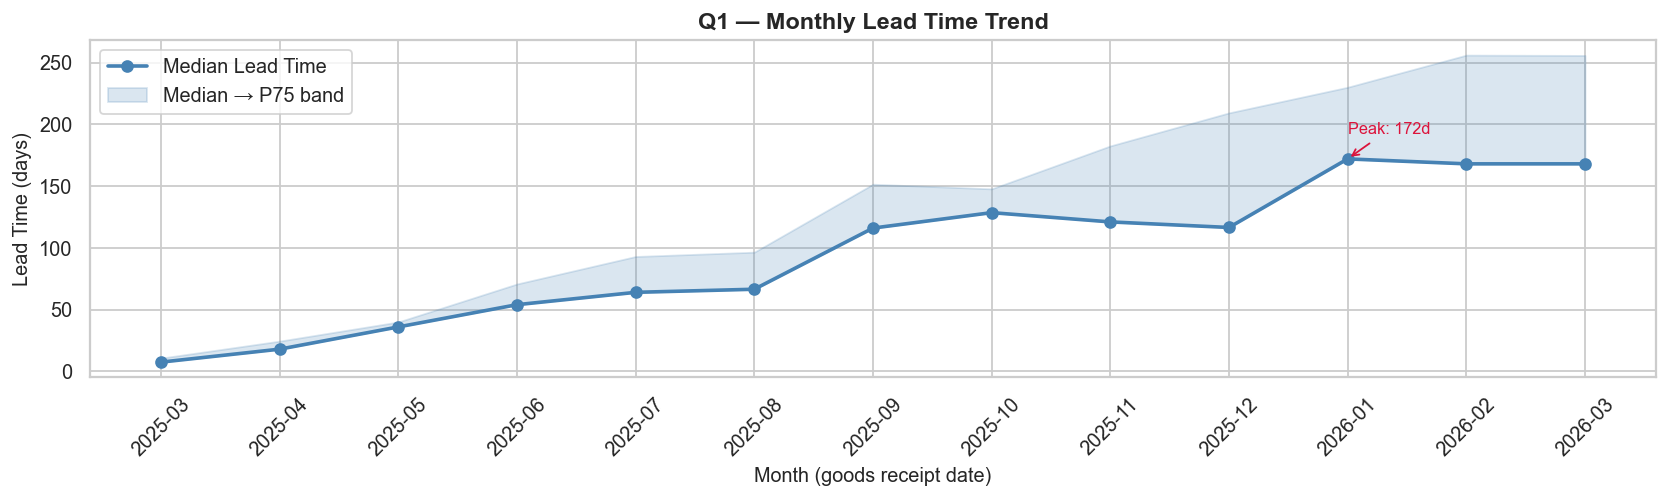

Trend: 8d (earliest month) → 168d (latest month)
Change: +160 days over the observation period


In [10]:
# ── Monthly trend ────────────────────────────────────────────────────────────
df_lt['receipt_month'] = pd.to_datetime(df_lt['receipt_date']).dt.to_period('M')

df_monthly = (df_lt.groupby('receipt_month')['lead_time_days']
                   .agg(median='median', p75=lambda x: x.quantile(0.75))
                   .reset_index())
df_monthly['receipt_month_str'] = df_monthly['receipt_month'].astype(str)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_monthly['receipt_month_str'], df_monthly['median'],
        marker='o', linewidth=2, label='Median Lead Time', color='steelblue')
ax.fill_between(df_monthly['receipt_month_str'],
                df_monthly['median'], df_monthly['p75'],
                alpha=0.2, color='steelblue', label='Median → P75 band')

# ── Annotate the peak ────────────────────────────────────────────────────────
peak_idx  = df_monthly['median'].idxmax()
peak_val  = df_monthly['median'].iloc[peak_idx]
peak_mon  = df_monthly['receipt_month_str'].iloc[peak_idx]
ax.annotate(f"Peak: {peak_val:.0f}d",
            xy=(peak_mon, peak_val),
            xytext=(peak_mon, peak_val + 20),
            arrowprops=dict(arrowstyle='->', color='crimson'),
            color='crimson', fontsize=9)

ax.set_title("Q1 — Monthly Lead Time Trend", fontweight='bold')
ax.set_xlabel("Month (goods receipt date)")
ax.set_ylabel("Lead Time (days)")
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig("q1_lead_time_trend.png", bbox_inches='tight')
plt.show()

# Print the trend direction for the findings cell
first_med = df_monthly['median'].iloc[0]
last_med  = df_monthly['median'].iloc[-1]
print(f"Trend: {first_med:.0f}d (earliest month) → {last_med:.0f}d (latest month)")
print(f"Change: +{last_med - first_med:.0f} days over the observation period")

#### Key Findings — Question 1

---

**⚠️ Data Quality Note**  
477 records (47.8% of raw joins) were removed due to negative lead times — a known artefact of the ERP simulation where receipt events are sometimes linked to POs created after the movement date. This does not occur in real SAP systems.  
**521 valid delivery records across 100 vendors and 624 purchase orders** were retained.

---

| Metric | Value |
|---|---|
| Valid deliveries analysed | 521 |
| Median lead time | **100 days** |
| Mean lead time | **120 days** |
| Std deviation | 85.4 days |
| Interquartile range (P25–P75) | 50 – 182 days (**132-day spread**) |
| 90th percentile | 249 days |
| Fastest delivery observed | 0 days (same-day) |
| Slowest delivery observed | 342 days (~11 months) |

---

**Finding 1 — The distribution is strongly right-skewed (skew ≈ 0.55)**  
The mean (120d) sits 20 days above the median (100d), pulled upward by a tail of very slow deliveries. This means the *typical* supplier performs better than the average suggests — but a meaningful subset of deliveries take 6–11 months,  
representing a significant operational risk.

**Finding 2 — Lead time variability is extremely high**  
The IQR spans 132 days. A procurement planner cannot rely on a single lead time estimate — the gap between a fast delivery (P25 = 50d) and a slow one (P75 = 182d) is larger than many companies' entire safety stock buffer.

**Finding 3 — Lead times have been deteriorating over the observation period**  
The monthly trend shows a clear upward trajectory, rising from ~10 days in early 2025 to ~170 days by early 2026. The P75 band is also widening, meaning deliveries are becoming both slower *and* less predictable over time. This is the most operationally concerning finding in this section.

> **Implication for Q2:** Given the high variability, on-time % will be a more meaningful reliability metric than average lead time alone. A vendor with a consistent 90-day lead time is far preferable to one averaging 90 days with a standard deviation of 80.
